In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc
from scripts.Hamiltonian import Hamiltonian


In [2]:
widthD = 40

X, Y = widthD, 40
lattice = Lattice(X, Y)

t = 1
T = 0.01

muD = 0.15 * t
mu = np.ones(lattice.X) * muD

U = -3* np.ones(lattice.X)
V_prime = None

V0 = 6 * t
V = V0 * np.ones(lattice.X)

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.1, 0.1, -0.1, -0.1])

In [4]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=500, temperature=T,verbose=True, mixing=0.6)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.0053050060078717
Relative error: 5305006007.8717
Average old: 0j
Average: (0.00018949226648787447+0j)
F_xplus:
Absolute error: 0.2195472608216288
Relative error: 2.1954726081943328
Average old: (0.09999999999999999+0j)
Average: (0.1348626035109924+0j)
F_xmin:
Absolute error: 0.21954726082162873
Relative error: 2.1954726081943323
Average old: (0.09999999999999999+0j)
Average: (0.13486260351099238+0j)
F_yplus:
Absolute error: 0.24082205007232757
Relative error: 2.4082205007473583
Average old: (-0.09999999999999999+0j)
Average: (-0.13806497434040313-1.2760625889285394e-17j)
F_ymin:
Absolute error: 0.24082205007232757
Relative error: 2.4082205007473583
Average old: (-0.09999999999999999+0j)
Average: (-0.13806497434040313+1.2760625889285394e-17j)
Fuu_xplus:
Absolute error: 1.8156730565980344e-16
Relative error: 0.00018156730565980342
Average old: 0j
Average: (2.7418976634097216e-17+0j)
Fuu_xmin:
Absolute error: 1.7269798618684413e-16
Relative error: 0.00017269798618684

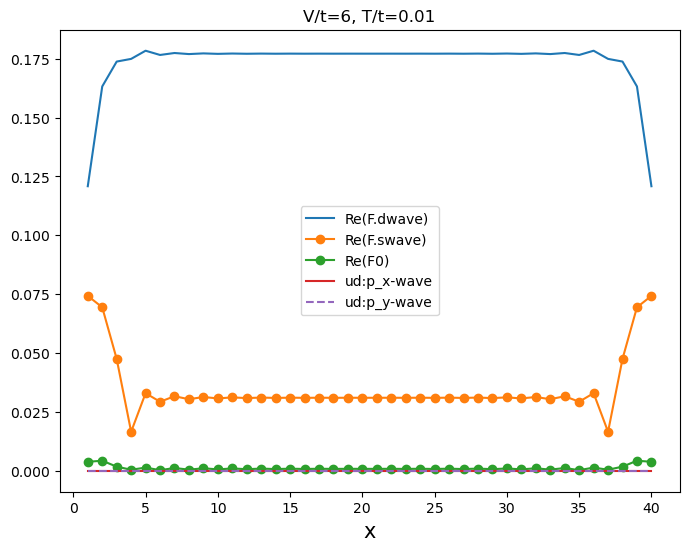

In [5]:
x = np.arange(1, widthD + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.abs(F.swave), '-o', label="Re(F.swave)")
axs.plot(x, np.abs(H.F0), '-o', label="Re(F0)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [6]:
print(F.dwave[X//2])

(0.17713055546705359+0j)


In [7]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.61 + 1e-12, 0.01)
])  # 109 temps total
print(len(temps))

70


In [40]:
width = 40
X, Y = width, 200
lattice = Lattice(X, Y)

t = 1
T = 0.001

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

U = None
V_prime = None

V0 = 2 * t
V = V0 * np.ones(lattice.X)
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_t=V,
                F_init=[0.001, -0.001, 0.001j, -0.001j])


In [41]:
bdg_sc(H, atol=1e-3, rtol=1e-1, maxiter=200, temperature=T,verbose=True, mixing=0.75)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 1.8394256010984227e-16
Relative error: 0.00018394256010984228
Average old: 0j
Average: (-4.9429577761426555e-18+0j)
F_xplus:
Absolute error: 0.0007734193525008132
Relative error: 0.7734193517273937
Average old: (0.0010000000000000002+0j)
Average: (0.001031889743654259+0j)
F_xmin:
Absolute error: 0.0007734193525007302
Relative error: 0.7734193532741496
Average old: (-0.0010000000000000002+0j)
Average: (-0.0010318897436542372+0j)
F_yplus:
Absolute error: 0.005410605565878146
Relative error: 5.410605565878147
Average old: 0.0010000000000000002j
Average: (-5.8523743000720835e-18+0.0018536255484964273j)
F_ymin:
Absolute error: 0.005410605565878146
Relative error: 5.410605565878147
Average old: -0.0010000000000000002j
Average: (-5.8523743000720835e-18-0.0018536255484964273j)
Fuu_xplus:
Absolute error: 1.0414085853338211e-17
Relative error: 1.0414085853338211e-05
Average old: 0j
Average: (4.65367775815066e-19+0j)
Fuu_xmin:
Absolute error: 1.0899479468633978e-17
Relative er

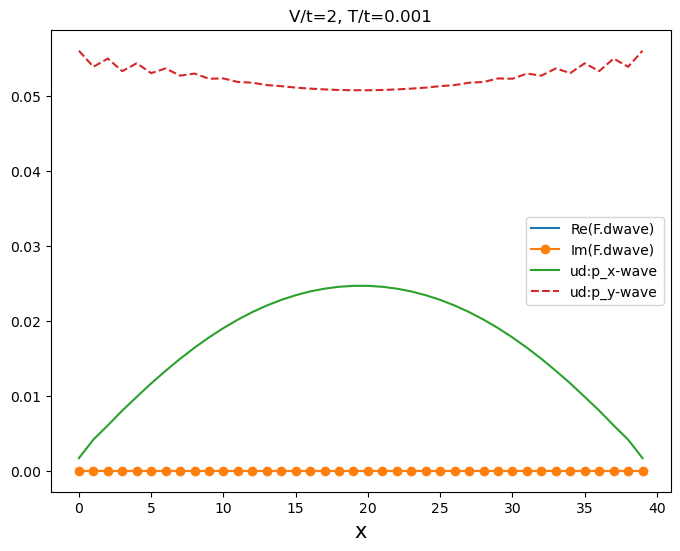

In [42]:
x = np.arange(0, width)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [37]:
print(F.py[X//2])
print(F.px[X//2])


0.0009088988736287557j
(0.0008263615814850272+0j)


In [39]:
temps = np.concatenate([
    np.arange(0.001, 0.100 + 1e-12, 0.005),
    np.arange(0.102, 0.120+1e-12, 0.0001),
    np.arange(0.125, 0.150 + 1e-12, 0.005),
])  # 207 temps total
print(len(temps))
print(temps)

207
[0.001  0.006  0.011  0.016  0.021  0.026  0.031  0.036  0.041  0.046
 0.051  0.056  0.061  0.066  0.071  0.076  0.081  0.086  0.091  0.096
 0.102  0.1021 0.1022 0.1023 0.1024 0.1025 0.1026 0.1027 0.1028 0.1029
 0.103  0.1031 0.1032 0.1033 0.1034 0.1035 0.1036 0.1037 0.1038 0.1039
 0.104  0.1041 0.1042 0.1043 0.1044 0.1045 0.1046 0.1047 0.1048 0.1049
 0.105  0.1051 0.1052 0.1053 0.1054 0.1055 0.1056 0.1057 0.1058 0.1059
 0.106  0.1061 0.1062 0.1063 0.1064 0.1065 0.1066 0.1067 0.1068 0.1069
 0.107  0.1071 0.1072 0.1073 0.1074 0.1075 0.1076 0.1077 0.1078 0.1079
 0.108  0.1081 0.1082 0.1083 0.1084 0.1085 0.1086 0.1087 0.1088 0.1089
 0.109  0.1091 0.1092 0.1093 0.1094 0.1095 0.1096 0.1097 0.1098 0.1099
 0.11   0.1101 0.1102 0.1103 0.1104 0.1105 0.1106 0.1107 0.1108 0.1109
 0.111  0.1111 0.1112 0.1113 0.1114 0.1115 0.1116 0.1117 0.1118 0.1119
 0.112  0.1121 0.1122 0.1123 0.1124 0.1125 0.1126 0.1127 0.1128 0.1129
 0.113  0.1131 0.1132 0.1133 0.1134 0.1135 0.1136 0.1137 0.1138 0.1139
 0.1